In [1]:
import sys
sys.path.append('../')
sys.path.append('../../')
import h5py
import numpy as np
import matplotlib.pyplot as plt

[7.99861250e+03 1.14884561e+03 5.65389938e+02 3.24864219e+02
 2.01528700e+02 1.29199388e+02 8.34130365e+01 5.73102677e+01
 4.01289848e+01 2.81708852e+01 1.93720891e+01 1.38881933e+01
 1.01129643e+01 7.24700872e+00 5.06789523e+00 3.66649604e+00
 2.69020989e+00 1.97502650e+00 1.39944179e+00 1.02283941e+00
 7.61728746e-01 5.64650114e-01 4.07246335e-01 3.06224970e-01
 2.32553139e-01 1.79144847e-01 1.35195265e-01 1.08375038e-01
 8.94281821e-02 7.70359848e-02 6.61121819e-02 6.14810013e-02
 6.12393346e-02 6.35746256e-02 6.72354241e-02 7.61910891e-02
 9.14493880e-02 1.14178630e-01 1.39800815e-01 1.80216370e-01
 2.38746589e-01 3.20284997e-01 4.18205839e-01 5.62596861e-01
 7.74844027e-01 1.07235040e+00 1.42844641e+00 1.96393078e+00
 2.74188636e+00 3.84396318e+00 5.18915597e+00 7.29752175e+00
 1.03521154e+01 1.46781367e+01 2.00573676e+01 2.86368117e+01
 4.09749405e+01 5.94697115e+01 8.53904310e+01 1.29454524e+02
 2.02949751e+02 3.34466473e+02 5.77393425e+02 1.15160112e+03]


/tmp/ipykernel_1721882/2915017695.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


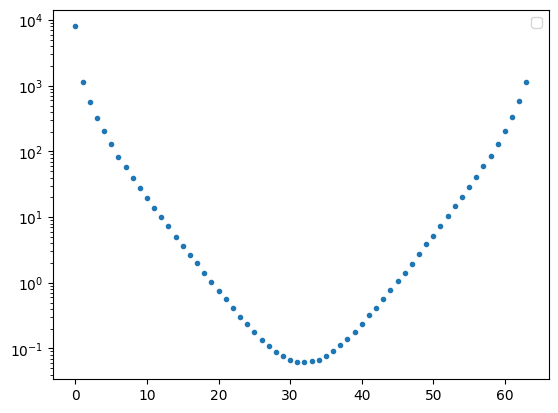

In [2]:
file = 'pipi_2pt_nvec_64_tsrc_24_task1.h5'
with h5py.File(file) as f:
    data = f['/pipi_000/pipi/direct/cfg_400_tsrc_avg'][:]

print(data)
import matplotlib.pyplot 
plt.plot(np.arange(64), data, '.', )
plt.yscale('log')
plt.legend()
plt.savefig('pipi.jpg')


(2, 64)


/tmp/ipykernel_1721882/1051541956.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


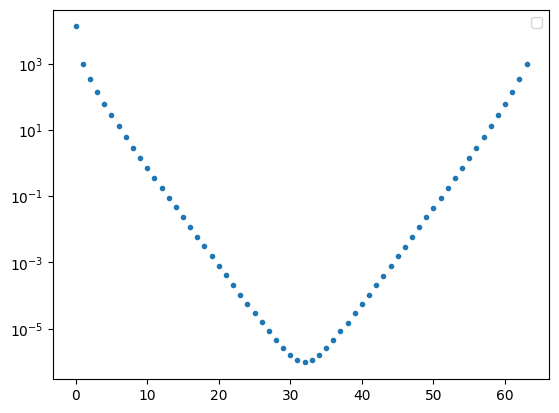

In [3]:
file = 'utils/dpi_test.h5'
data = np.zeros((2,64,24))
with h5py.File(file,'r') as f:
    for isrc,tsrc in enumerate(f['/Dpi_000/Dpi/6/']):
        t = int(tsrc.split('_')[1])
        cfg_list = list(f[f'/Dpi_000/Dpi/6/{tsrc}/'])
        for icfg, cfg in enumerate(sorted(cfg_list, key=lambda cfg: int(cfg[4:]))):
            cfg_data = np.array(f[f'/Dpi_000/Dpi/6/{tsrc}/{cfg}/cfg{icfg+1}'][:])
            data[icfg, :, t] = cfg_data
for i in range(24):
    data[:,:, i] = np.roll(data[:, :, i], -4*i, axis=1)
data = data.mean(axis=2)


print(data.shape)
import matplotlib.pyplot 
plt.plot(np.arange(64), data[1,:], '.')
plt.yscale('log')
plt.legend()
plt.savefig('pipi.jpg')
